In [1]:
DATE = 'JUN9'
default_json  = '_json/default_params.json'
controller_mode="original"

In [2]:
from pathlib import Path
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json

RC_SIMULATOR = "ETHlib"
if RC_SIMULATOR not in sys.path:
    sys.path.insert(0, RC_SIMULATOR)

from _BR_ import *
from _zone_ import DebugZone as Zone
import supply_system
import emission_system

case = RCCase(
    year=2023,
    loc_json              = Path("_json/location_params.json"),
    geo_json              = Path("_json/geo_params.json"),
    default_json          = Path("_json/default_params.json"),
    epw_path              = Path("../src/_base/epw/ED-TMYx.2023.epw"),
    occupancy_profile_csv = Path("ETHlib/auxiliary/schedules_el_OFFICE.csv"),
    Zone=Zone,
    supply_system=supply_system,
    emission_system=emission_system,
)

DEFAULT_PARAMS = json.loads(Path(default_json).read_text())
RUN_DIR = Path(f"_json/_run/{DATE}")
uq_json_path = RUN_DIR / "OAT.json"

In [3]:
meter_path = "_data/Metering_ISO.csv"

meter_daily = load_meter_heating(
    meter_path,
    "Main Heating",
    case.geometry["FLOOR_AREA"],
    "D",
)

meter_hourly = load_meter_heating(
    meter_path,
    "Main Heating",
    case.geometry["FLOOR_AREA"],
    "h",
)

Metering Timestamp: 2023-01-01 00:00:00 ~ 2023-12-31 23:00:00
Metering Timestamp: 2023-01-01 00:00:00 ~ 2023-12-31 23:00:00


# RUN

In [4]:
from scipy.stats import qmc
def make_lhs_samples_from_uq_json(uq_json_path, N=100, save_csv=True):
    uq_json_path = Path(uq_json_path)

    with open(uq_json_path, "r", encoding="utf-8") as f:
        uq_config = json.load(f)

    N = N
    seed = uq_config["seed"]
    params = uq_config["parameters"]

    param_names = list(params.keys())
    n_dim = len(param_names)

    sampler = qmc.LatinHypercube(d=n_dim, seed=seed)
    lhs_unit = sampler.random(n=N)

    samples = pd.DataFrame(index=range(N), columns=param_names, dtype=float)

    for i, name in enumerate(param_names):
        lower = params[name]["lower"]
        upper = params[name]["upper"]

        samples[name] = lower + lhs_unit[:, i] * (upper - lower)

    samples.index = [f"sample_{i+1:03d}" for i in range(N)]

    if save_csv:
        output_path = uq_json_path.parent / f"{uq_json_path.stem}_lhs_samples.csv"
        samples.to_csv(output_path)
        print(f"Saved LHS samples to: {output_path}")

    return samples

def run_lhs_samples(
    lhs_samples,
    controller_mode="original",
):
    """
    Run model for each row in lhs_samples.

    Each row is injected as sampled_params into run_model().
    """

    results = {}
    euis = {}

    for sample_id, row in lhs_samples.iterrows():
        sampled_params = row.to_dict()

        res, eui, _ = run_model_case(
            case = case,
            sampled_params=sampled_params,
            controller_mode=controller_mode,
        )
        
        results[sample_id] = res
        euis[sample_id] = eui

        print(f"Finished {sample_id}")

    eui_df = pd.DataFrame(euis).T

    return results, eui_df

In [5]:
lhs_samples = make_lhs_samples_from_uq_json(
    uq_json_path=uq_json_path,
    N = 160,
    save_csv=True,
)

lhs_results_occ, lhs_eui_df_occ = run_lhs_samples(
    lhs_samples=lhs_samples,
    controller_mode=controller_mode,
)

lhs_eui_df_occ

Saved LHS samples to: _json\_run\JUN9\OAT_lhs_samples.csv
Finished sample_001
Finished sample_002
Finished sample_003
Finished sample_004
Finished sample_005
Finished sample_006
Finished sample_007
Finished sample_008
Finished sample_009
Finished sample_010
Finished sample_011
Finished sample_012
Finished sample_013
Finished sample_014
Finished sample_015
Finished sample_016
Finished sample_017
Finished sample_018
Finished sample_019
Finished sample_020
Finished sample_021
Finished sample_022
Finished sample_023
Finished sample_024
Finished sample_025
Finished sample_026
Finished sample_027
Finished sample_028
Finished sample_029
Finished sample_030
Finished sample_031
Finished sample_032
Finished sample_033
Finished sample_034
Finished sample_035
Finished sample_036
Finished sample_037
Finished sample_038
Finished sample_039
Finished sample_040
Finished sample_041
Finished sample_042
Finished sample_043
Finished sample_044
Finished sample_045
Finished sample_046
Finished sample_047
Fi

,HeatingEnergy,CoolingEnergy
sample_001,25.492888,0.536845
sample_002,47.165408,0.166233
sample_003,32.652230,0.066270
sample_004,43.516992,0.028777
sample_005,19.855966,0.259429
...,...,...
sample_156,44.045929,0.114490
sample_157,11.558609,0.778417
sample_158,27.312838,0.016237
sample_159,42.649251,0.046298


In [ ]:
def calc_metrics(sim, obs):

    df = pd.concat(
        [sim.rename("sim"), obs.rename("obs")],
        axis=1,
    ).dropna()

    error = df["sim"] - df["obs"]

    rmse = np.sqrt(np.mean(error ** 2))
    cvrmse = rmse / df["obs"].mean() * 100
    nmbe = error.sum() / ((len(df) - 1) * df["obs"].mean()) * 100

    return {
        "n": len(df),
        "rmse": rmse,
        "cvrmse": cvrmse,
        "nmbe": nmbe,
        "sim_eui": df["sim"].sum(),
        "meter_eui": df["obs"].sum(),
        "bias_eui": df["sim"].sum() - df["obs"].sum(),
    }


def compare_lhs_to_meter(
    lhs_results,
    meter_series,
    variable="HeatingEnergy",
    freq_label="hourly",
):
    rows = []

    for sample_id, res in lhs_results.items():
        sim = res[variable].copy()

        metrics = calc_metrics(sim, meter_series)

        rows.append({
            "sample_id": sample_id,
            "freq": freq_label,
            **metrics,
        })

    metrics_df = pd.DataFrame(rows).set_index("sample_id")

    return metrics_df

In [7]:
start = "2023-02-01 00:00"
end   = "2023-03-10 23:00"


lhs_results_daily = {
    sample_id: res[["HeatingEnergy"]].resample("D").sum()
    for sample_id, res in lhs_results_occ.items()
}

lhs_metrics_daily = compare_lhs_to_meter(
    lhs_results=lhs_results_daily,
    meter_series=meter_daily,
    variable="HeatingEnergy",
    freq_label="daily",
)

# SAVE FOR BAYESIAN CALIBRATION

In [ ]:
def save_bayesian_calibration_files(
    lhs_samples,
    lhs_results,
    meter_series,
    variable="HeatingEnergy",
    freq="D",
    start=None,
    end=None,
    output_dir=Path(f"json/UQ/{DATE}_lhs"),
):
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    TT = lhs_samples.copy()
    sim_series = {}

    for sample_id, res in lhs_results.items():
        sim = res[variable].copy()

        if start is not None or end is not None:
            sim = sim.loc[start:end]

        if freq is not None:
            sim = sim.resample(freq).sum()

        sim_series[sample_id] = sim

    Y = pd.DataFrame(sim_series)

    obs = meter_series.copy()

    if start is not None or end is not None:
        obs = obs.loc[start:end]

    if freq is not None:
        obs = obs.resample(freq).sum()

    obs.name = "obs"
    common_index = obs.index.intersection(Y.index)

    obs = obs.loc[common_index]
    Y = Y.loc[common_index]
    TT.to_csv(output_dir / "TT.csv")
    Y.to_csv(output_dir / "Y.csv")
    obs.to_csv(output_dir / "obs.csv")

    print(f"Saved Bayesian calibration files to: {output_dir}")
    print(f"Period: {obs.index.min()} to {obs.index.max()}")
    print(f"TT shape:  {TT.shape}")
    print(f"Y shape:   {Y.shape}")
    print(f"obs shape: {obs.shape}")

    return TT, Y, obs

In [9]:
output_dir = RUN_DIR

TT, Y, obs = save_bayesian_calibration_files(
    lhs_samples=lhs_samples,
    lhs_results=lhs_results_daily,
    meter_series=meter_hourly,
    variable="HeatingEnergy",
    freq="D",
    start=start,
    end=end,
    output_dir=output_dir,
)

Saved Bayesian calibration files to: _json\_run\JUN9
Period: 2023-02-01 00:00:00 to 2023-03-10 00:00:00
TT shape:  (160, 4)
Y shape:   (38, 160)
obs shape: (38,)


In [10]:
plt.rcParams.update({
    "font.family": "Arial",
    "mathtext.fontset": "stix",
    "font.size": 14,
    "axes.labelsize": 18,
    "legend.fontsize": 12,
})

# Deterministic CAL

In [11]:
from pathlib import Path
import json


def select_top_samples_as_posterior(
    lhs_samples,
    lhs_metrics,
    Y,
    obs,
    uq_json_path,
    output_dir,
    top_n=10,
    metric="cvrmse",
    ascending=True,
):
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    top_ids = (
        lhs_metrics
        .sort_values(metric, ascending=ascending)
        .head(top_n)
        .index
        .tolist()
    )

    posterior_TT = lhs_samples.loc[top_ids].copy()
    posterior_Y = Y[top_ids].copy()
    posterior_obs = obs.copy()
    posterior_metrics = lhs_metrics.loc[top_ids].copy()

    posterior_TT.to_csv(output_dir / "posterior_TT.csv")
    posterior_Y.to_csv(output_dir / "posterior_Y.csv")
    posterior_obs.to_csv(output_dir / "posterior_obs.csv")
    posterior_metrics.to_csv(output_dir / "posterior_metrics.csv")

    posterior_samples_json = {
        "selection_method": "top_n_by_metric",
        "top_n": top_n,
        "metric": metric,
        "source_uq_json": str(uq_json_path),
        "selected_samples": top_ids,
        "parameters": posterior_TT.to_dict(orient="index"),
    }

    with open(output_dir / "posterior_samples.json", "w", encoding="utf-8") as f:
        json.dump(posterior_samples_json, f, indent=2)

    print(f"Saved top-{top_n} posterior-like samples to: {output_dir}")
    print("Selected samples:")
    print(top_ids)

    return posterior_TT, posterior_Y, posterior_obs, posterior_metrics

In [12]:
posterior_dir = RUN_DIR

posterior_TT, posterior_Y, posterior_obs, posterior_metrics = select_top_samples_as_posterior(
    lhs_samples=lhs_samples,
    lhs_metrics=lhs_metrics_daily,
    Y=Y,
    obs=obs,
    uq_json_path=uq_json_path,
    output_dir=posterior_dir,
    top_n=10,
    metric="cvrmse",
    ascending=True,
)

Saved top-10 posterior-like samples to: _json\_run\JUN9
Selected samples:
['sample_125', 'sample_073', 'sample_112', 'sample_002', 'sample_151', 'sample_159', 'sample_107', 'sample_030', 'sample_156', 'sample_085']


Viewing period: 2023-01-20 00:00:00 to 2023-03-10 00:00:00
Number of matched timesteps: 38
Coverage by q05-q95: 23.7%
Coverage by IQR: 15.8%


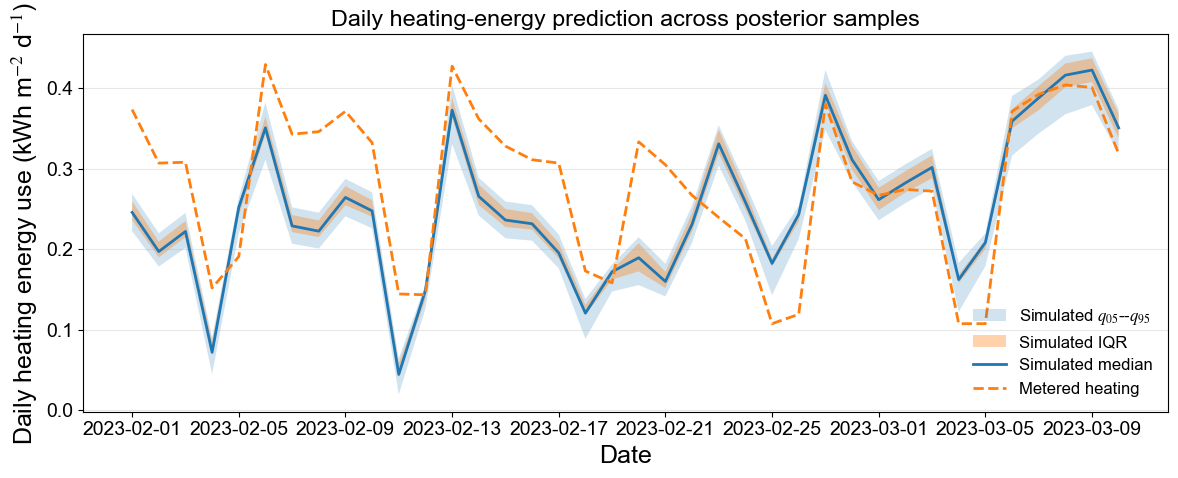

In [13]:
def make_sim_summary(Y):
    """
    Convert simulation ensemble Y into summary quantiles.

    Y:
        rows = timestamps
        columns = simulation samples
    """

    sim_summary = pd.DataFrame(index=Y.index)

    sim_summary["q05"] = Y.quantile(0.05, axis=1)
    sim_summary["q25"] = Y.quantile(0.25, axis=1)
    sim_summary["median"] = Y.median(axis=1)
    sim_summary["q75"] = Y.quantile(0.75, axis=1)
    sim_summary["q95"] = Y.quantile(0.95, axis=1)

    return sim_summary
sim_summary = make_sim_summary(posterior_Y)
coverage = plot_heating_coverage(
    sim_summary=sim_summary,
    meter_series=posterior_obs,
    start_date="2023-01-20",
    end_date="2023-03-10",
    y_label=r"Daily heating energy use (kWh m$^{-2}$ d$^{-1}$)",
    title="Daily heating-energy prediction across posterior samples"
)

# ECM evaluations

In [ ]:
def calc_calibration_metrics(sim, obs, p=0):
    df = pd.concat(
        [sim.rename("sim"), obs.rename("obs")],
        axis=1
    ).dropna()

    n = len(df)
    
    if n <= p:
        raise ValueError("Number of matched timesteps must be larger than p.")

    error = df["sim"] - df["obs"]

    rmse = np.sqrt((error ** 2).sum() / (n - p))
    cvrmse = rmse / df["obs"].mean() * 100

    nmbe = error.sum() / ((n - p) * df["obs"].mean()) * 100

    return {
        "n": n,
        "p": p,
        "rmse": rmse,
        "cvrmse": cvrmse,
        "nmbe": nmbe,
        "sim_sum": df["sim"].sum(),
        "obs_sum": df["obs"].sum(),
        "bias_sum": df["sim"].sum() - df["obs"].sum(),
    }

posterior_median = posterior_Y.median(axis=1)

median_metrics = calc_calibration_metrics(
    sim=posterior_median,
    obs=posterior_obs.squeeze(),
    p=0
)

print(f"Posterior median CVRMSE = {median_metrics['cvrmse']:.2f}%")
print(f"Posterior median NMBE   = {median_metrics['nmbe']:.2f}%")

Posterior median CVRMSE = 28.44%
Posterior median NMBE   = -10.59%


# ECM evaluations

In [36]:
from tqdm.auto import tqdm

def show_progress(
    iterable,
    total=None,
    desc="Running",
    unit="item",
    mininterval=1.0,
    miniters=1,
):
    return tqdm(
        iterable,
        total=total,
        desc=desc,
        unit=unit,
        mininterval=mininterval,
        miniters=miniters,
    )

In [38]:
def run_posterior_ecm_samples(
    posterior_TT,
    run_model_func,
    extra_params=None,
    controller_mode="original",
):
    results = {}
    euis = {}

    if extra_params is None:
        extra_params = {}

    for sample_id, row in show_progress(
        posterior_TT.iterrows(),
        total=len(posterior_TT),
        desc="Running posterior samples",
        unit="sample",
    ):
        sampled_params = row.to_dict()
        sampled_params.update(extra_params)

        res, eui, _ = run_model_case(
            case=case,
            sampled_params=sampled_params,
            controller_mode=controller_mode,
        )

        results[sample_id] = res
        euis[sample_id] = eui

    eui_df = pd.DataFrame(euis).T

    return results, eui_df

baseline_results, baseline_eui = run_posterior_ecm_samples(
    posterior_TT=posterior_TT,
    run_model_func=run_model,
    extra_params=None,
    controller_mode="original",
)

Running posterior samples: 100%|██████████| 10/10 [00:05<00:00,  1.67sample/s]
